Notebook 03: Esperimento Embedding Statici (Custom vs Pre-trained)
Questo notebook implementa il confronto tra Word2Vec (addestrato da zero sulle issue) e GloVe (pre-addestrato su Wikipedia) per la classificazione binaria di Issue GitHub (Bug vs Feature).

In [16]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
# NLP & Embedding
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import gensim.downloader as api

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("Librerie importate con successo!")

Librerie importate con successo!


Caricamento Dati e Label Encoding

In [5]:
# Caricamento dei dataset (Modifica i percorsi se necessario)
train_df = pd.read_csv('../data/train_set.csv')
test_df = pd.read_csv('../data/test_set.csv')

# Conversione della variabile target ("bug", "feature") in numerica (0, 1)
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

print(f"Classi mappate: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Dimensioni Train: {train_df.shape} | Dimensioni Test: {test_df.shape}")

Classi mappate: {'bug': 0, 'feature': 1}
Dimensioni Train: (32650, 2) | Dimensioni Test: (13994, 2)


Tokenizzazione Leggera con Rimozione Stopwords

In [6]:
def tokenize_and_filter(text):
    # simple_preprocess converte in minuscolo, toglie punteggiatura e tokenizza
    tokens = simple_preprocess(str(text))
    # Rimuoviamo le stopwords per evitare che "inquinino" la media matematica dei vettori
    return [token for token in tokens if token not in STOPWORDS]

# Applicazione della tokenizzazione
print("Tokenizzazione in corso...")
train_df['tokens'] = train_df['text'].apply(tokenize_and_filter)
test_df['tokens'] = test_df['text'].apply(tokenize_and_filter)
print("Tokenizzazione completata!")

Tokenizzazione in corso...
Tokenizzazione completata!


Word2Vec custom (Addestrato da zero)

In [7]:
from gensim.models import Word2Vec

print("Addestramento di Word2Vec Custom sui dati di Train...")
# Addestriamo SOLO sul train set per evitare data leakage
w2v_model = Word2Vec(
    sentences=train_df['tokens'],
    vector_size=100,
    window=5,
    sg=1,          # Skip-gram
    min_count=2,   # Ignora parole uniche (potenziali refusi)
    workers=4      # Ottimizzato per CPU multi-core
)
print("Addestramento completato!")
print(f"Vocabolario Word2Vec Custom: {len(w2v_model.wv)} parole uniche.")

Addestramento di Word2Vec Custom sui dati di Train...
Addestramento completato!
Vocabolario Word2Vec Custom: 77441 parole uniche.


Funzione di Aggregazione (Sentence Vector) con Gestione OOV

In [8]:
def get_mean_vector(model, tokens, vector_size=100):
    # Estrae i vettori solo per le parole presenti nel vocabolario del modello
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    # Se nessuna parola è nel vocabolario (o testo vuoto), restituisce un vettore di zeri
    if not valid_vectors:
        return np.zeros(vector_size)
    
    # Fa la media matematica dei vettori validi
    return np.mean(valid_vectors, axis=0)

# Generazione delle matrici delle feature per Word2Vec Custom
X_train_w2v = np.vstack(train_df['tokens'].apply(lambda x: get_mean_vector(w2v_model, x)))
X_test_w2v = np.vstack(test_df['tokens'].apply(lambda x: get_mean_vector(w2v_model, x)))

print(f"Matrice Train Word2Vec: {X_train_w2v.shape}")
print(f"Matrice Test Word2Vec: {X_test_w2v.shape}")

Matrice Train Word2Vec: (32650, 100)
Matrice Test Word2Vec: (13994, 100)


GloVe Pre-addestrato (Wikipedia 100d)

In [9]:
print("Caricamento di GloVe (glove-wiki-gigaword-100) in corso...")
# Questo modello è leggerissimo (~120MB) ed efficiente per macchine con 8GB di RAM
glove_model = api.load("glove-wiki-gigaword-100")
print("GloVe caricato con successo!")

Caricamento di GloVe (glove-wiki-gigaword-100) in corso...
GloVe caricato con successo!


Generazione dell'Embedding GloVe per le Issue

In [10]:
def get_mean_vector_glove(model, tokens, vector_size=100):
    # KeyedVectors di GloVe usa la sintassi 'word in model' anziché 'word in model.wv'
    valid_vectors = [model[word] for word in tokens if word in model]
    
    if not valid_vectors:
        return np.zeros(vector_size)
    
    return np.mean(valid_vectors, axis=0)

# Generazione delle matrici delle feature per GloVe
X_train_glove = np.vstack(train_df['tokens'].apply(lambda x: get_mean_vector_glove(glove_model, x)))
X_test_glove = np.vstack(test_df['tokens'].apply(lambda x: get_mean_vector_glove(glove_model, x)))

print(f"Matrice Train GloVe: {X_train_glove.shape}")
print(f"Matrice Test GloVe: {X_test_glove.shape}")

Matrice Train GloVe: (32650, 100)
Matrice Test GloVe: (13994, 100)


Addestramento, Tuning e Valutazione dei Modelli
Creiamo una pipeline di addestramento e valutazione riutilizzabile per i 4 esperimenti.

In [21]:
# Dizionario globale per salvare i risultati finali di tutti i modelli
final_results = {}

def run_experiment(exp_name, X_train, y_train, X_test, y_test):
    from sklearn.metrics import precision_score, recall_score # Import locali per sicurezza
    
    print(f"\n=== ESECUZIONE ESPERIMENTO: {exp_name} ===")
    
    # 1. TUNING LOGISTIC REGRESSION (3 combinazioni, CV=3 per massima leggerezza)
    lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
    lr_params = {'C': [0.1, 1, 10]}
    grid_lr = GridSearchCV(lr, lr_params, cv=3, scoring='f1_macro', n_jobs=-1)
    grid_lr.fit(X_train, y_train)
    best_lr = grid_lr.best_estimator_
    
    # Predizione e Metriche LR
    y_pred_lr = best_lr.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr, average='macro')
    prec_lr = precision_score(y_test, y_pred_lr, average='macro')
    rec_lr = recall_score(y_test, y_pred_lr, average='macro')
    cm_lr = confusion_matrix(y_test, y_pred_lr).tolist()
    
    # 2. TUNING DECISION TREE (Massima profondità bloccata a 10 per evitare l'overfitting)
    dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    dt_params = {'max_depth': [5, 10]}
    grid_dt = GridSearchCV(dt, dt_params, cv=3, scoring='f1_macro', n_jobs=-1)
    grid_dt.fit(X_train, y_train)
    best_dt = grid_dt.best_estimator_
    
    # Predizione e Metriche DT
    y_pred_dt = best_dt.predict(X_test)
    acc_dt = accuracy_score(y_test, y_pred_dt)
    f1_dt = f1_score(y_test, y_pred_dt, average='macro')
    prec_dt = precision_score(y_test, y_pred_dt, average='macro')
    rec_dt = recall_score(y_test, y_pred_dt, average='macro')
    cm_dt = confusion_matrix(y_test, y_pred_dt).tolist()
    
    # Salvataggio di tutte le metriche nel dizionario globale
    final_results[f"{exp_name}_LogisticRegression"] = {
        "best_params": grid_lr.best_params_,
        "accuracy": acc_lr,
        "precision_macro": prec_lr,
        "recall_macro": rec_lr,
        "f1_macro": f1_lr,
        "confusion_matrix": cm_lr
    }
    final_results[f"{exp_name}_DecisionTree"] = {
        "best_params": grid_dt.best_params_,
        "accuracy": acc_dt,
        "precision_macro": prec_dt,
        "recall_macro": rec_dt,
        "f1_macro": f1_dt,
        "confusion_matrix": cm_dt
    }
    
    # Print di riepilogo a schermo
    print(f"\nRisultati [{exp_name} - Logistic Regression] (Best C: {grid_lr.best_params_['C']}):")
    print(f"   Accuracy: {acc_lr:.4f} | Precision: {prec_lr:.4f} | Recall: {rec_lr:.4f} | F1 Macro: {f1_lr:.4f}")
    
    print(f"Risultati [{exp_name} - Decision Tree] (Best Max Depth: {grid_dt.best_params_['max_depth']}):")
    print(f"   Accuracy: {acc_dt:.4f} | Precision: {prec_dt:.4f} | Recall: {rec_dt:.4f} | F1 Macro: {f1_dt:.4f}")

    # --- PLOTTING DELLE MATRICI DI CONFUSIONE (AFFIANCATE) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Definiamo le etichette per gli assi basandoci sul LabelEncoder (bug, feature)
    class_labels = le.classes_

    # Matrice Logistic Regression (a sinistra)
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_labels, yticklabels=class_labels)
    axes[0].set_title(f'{exp_name}\nLogistic Regression')
    axes[0].set_ylabel('Classe Reale')
    axes[0].set_xlabel('Classe Predetta')
    
    # Matrice Decision Tree (a destra)
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=class_labels, yticklabels=class_labels)
    axes[1].set_title(f'{exp_name}\nDecision Tree')
    axes[1].set_ylabel('Classe Reale')
    axes[1].set_xlabel('Classe Predetta')
    
    plt.tight_layout()
    
       
    # Salva il grafico personalizzando il nome in base all'esperimento
    plt.savefig(f'../figures/confusion_matrix_wordembeddings{exp_name.lower()}.png')
    plt.show()

    # Restituiamo le variabili grezze come tuple per utilizzarle fuori
    return (acc_lr, prec_lr, rec_lr, f1_lr, cm_lr, 
            acc_dt, prec_dt, rec_dt, f1_dt, cm_dt)

Esecuzione dei 4 Esperimenti


=== ESECUZIONE ESPERIMENTO: Word2Vec_Custom ===

Risultati [Word2Vec_Custom - Logistic Regression] (Best C: 1):
   Accuracy: 0.8621 | Precision: 0.8625 | Recall: 0.8621 | F1 Macro: 0.8620
Risultati [Word2Vec_Custom - Decision Tree] (Best Max Depth: 10):
   Accuracy: 0.8062 | Precision: 0.8070 | Recall: 0.8062 | F1 Macro: 0.8061


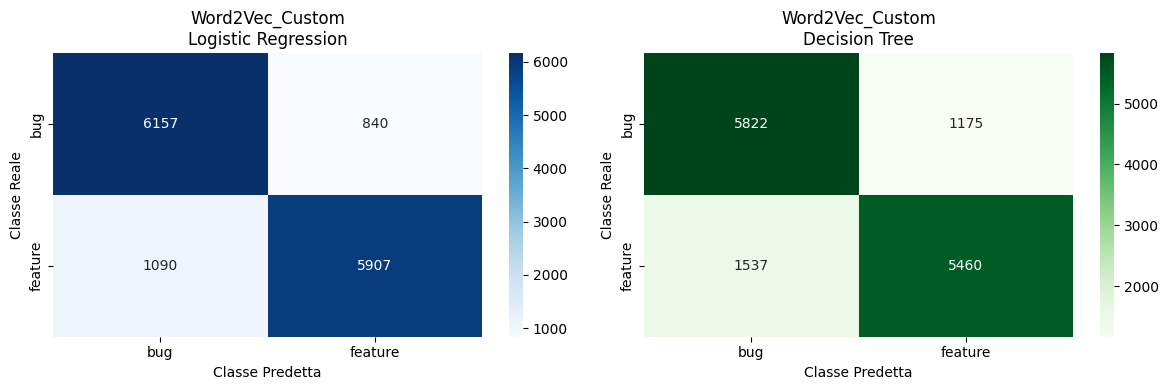


=== ESECUZIONE ESPERIMENTO: GloVe_Pretrained ===

Risultati [GloVe_Pretrained - Logistic Regression] (Best C: 10):
   Accuracy: 0.7988 | Precision: 0.7993 | Recall: 0.7988 | F1 Macro: 0.7987
Risultati [GloVe_Pretrained - Decision Tree] (Best Max Depth: 10):
   Accuracy: 0.7220 | Precision: 0.7245 | Recall: 0.7220 | F1 Macro: 0.7212


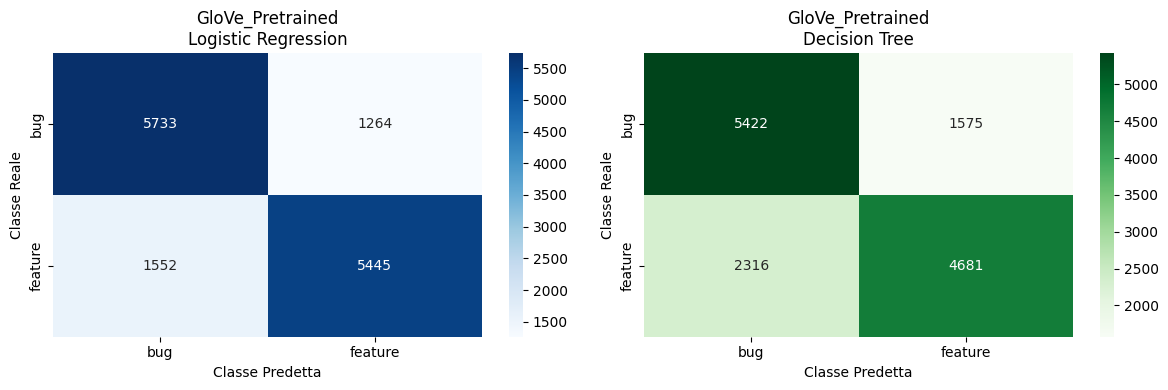

In [22]:
# # Svolgiamo i calcoli e salviamo le metriche in variabili locali fuori dalla funzione
(acc_w2v_lr, prec_w2v_lr, rec_w2v_lr, f1_w2v_lr, cm_w2v_lr,
 acc_w2v_dt, prec_w2v_dt, rec_w2v_dt, f1_w2v_dt, cm_w2v_dt) = run_experiment("Word2Vec_Custom", X_train_w2v, y_train, X_test_w2v, y_test)

(acc_glove_lr, prec_glove_lr, rec_glove_lr, f1_glove_lr, cm_glove_lr,
 acc_glove_dt, prec_glove_dt, rec_glove_dt, f1_glove_dt, cm_glove_dt) = run_experiment("GloVe_Pretrained", X_train_glove, y_train, X_test_glove, y_test)

Salvataggio risultati

In [25]:
# --- 1. COMPOSIZIONE STRUTTURA DIZIONARIO WORD2VEC ---
word2vec_results_json = {
    'logistic_regression': {
        'accuracy': float(acc_w2v_lr),
        'precision': float(prec_w2v_lr),
        'recall': float(rec_w2v_lr),
        'f1_score': float(f1_w2v_lr),
        'confusion_matrix': cm_w2v_lr
    },
    'decision_tree': {
        'accuracy': float(acc_w2v_dt),
        'precision': float(prec_w2v_dt),
        'recall': float(rec_w2v_dt),
        'f1_score': float(f1_w2v_dt),
        'confusion_matrix': cm_w2v_dt
    }
}

# --- 2. COMPOSIZIONE STRUTTURA DIZIONARIO GLOVE ---
glove_results_json = {
    'logistic_regression': {
        'accuracy': float(acc_glove_lr),
        'precision': float(prec_glove_lr),
        'recall': float(rec_glove_lr),
        'f1_score': float(f1_glove_lr),
        'confusion_matrix': cm_glove_lr
    },
    'decision_tree': {
        'accuracy': float(acc_glove_dt),
        'precision': float(prec_glove_dt),
        'recall': float(rec_glove_dt),
        'f1_score': float(f1_glove_dt),
        'confusion_matrix': cm_glove_dt
    }
}

output_json_path_w2v = "../results/word2vec_results.json"
with open(output_json_path_w2v, 'w', encoding='utf-8') as f:
    json.dump(word2vec_results_json, f, indent=4, ensure_ascii=False)
print(f"Risultati Word2Vec salvati in: {output_json_path_w2v}")

output_json_path_glove = "../results/glove_results.json"
with open(output_json_path_glove, 'w', encoding='utf-8') as f:
    json.dump(glove_results_json, f, indent=4, ensure_ascii=False)
print(f"Risultati GloVe salvati in: {output_json_path_glove}")


Risultati Word2Vec salvati in: ../results/word2vec_results.json
Risultati GloVe salvati in: ../results/glove_results.json
